In [ ]:
#Q1
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import TTestIndPower
from scipy import stats
#
analysis = TTestIndPower()
alpha = 0.05
power_target = 0.8
sd = 4                     
users_per_day_per_group = 300

In [ ]:
n4 =users_per_day_per_group*4 
d_min_4 = analysis.solve_power(effect_size=None, nobs1=n4, alpha=alpha,
                                power=power_target, ratio=1.0, alternative='two-sided')
mde_minutes_4 = d_min_4 *sd
print(f"Minimum detectable Cohen's d: {d_min_4:.4f}")
print(f"Minimum detectable difference: {mde_minutes_4:.4f} min({mde_minutes_4*60:.1f}sec)")

Minimum detectable Cohen's d: 0.1144
Minimum detectable difference: 0.4577 min (27.5sec)


The smallest difference ion the average time on app is 27.5 seconds.

In [ ]:
observed_diff = 0.5
se = np.sqrt(sd**2/n4 + sd**2/n4)
t_stat = observed_diff / se
df = 2*n4 - 2
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))
tcrit = stats.t.ppf(0.975, df)
ci_low, ci_high = observed_diff - tcrit*se, observed_diff + tcrit*se #got help from claude for the formulas
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")
print(f"95% CI on the difference: [{ci_low:.3f}, {ci_high:.3f}] minutes")

t = 3.062, p = 0.0022
95% CI on the difference: [0.180, 0.820] minutes


I wouldnt recommend discontinuing the test and rolling out B to everyone yet because the minimum observable effect is 0.5 and we're at 0.46 so we are right at the edge of what the data can actually tell us from just noise. Theres also only 4 days worth of data and not a full weeks worth of data so it might affect how we analyze the usage patterns and if certain days affect the results more than others. It would be worth asking the leadership for more time in each session so that it increases the average time,n which would help in confirming if it holds or not.

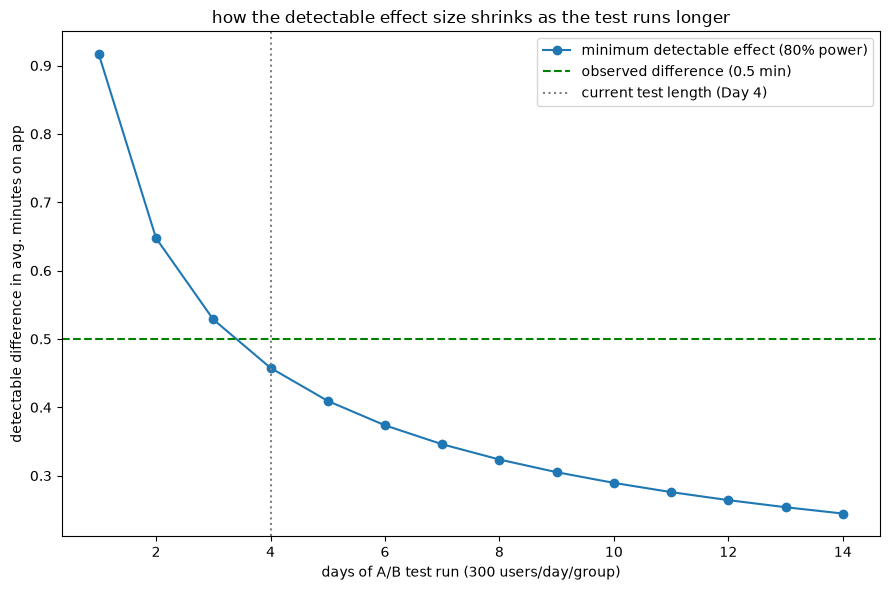

In [5]:
#Q3
days = np.arange(1, 15)
n_per_day = days * users_per_day_per_group
mde_by_day = np.array([
    analysis.solve_power(effect_size=None, nobs1=n, alpha=alpha, power=power_target,
                          ratio=1.0, alternative='two-sided') * sd
    for n in n_per_day
])

plt.figure(figsize=(9,6))
plt.plot(days, mde_by_day, marker='o', label='minimum detectable effect (80% power)')
plt.axhline(0.5, color='green', linestyle='--', label='observed difference (0.5 min)')
plt.axvline(4, color='gray', linestyle=':', label='current test length (Day 4)')
plt.xlabel('days of A/B test run (300 users/day/group)')
plt.ylabel('detectable difference in avg. minutes on app')
plt.title('how the detectable effect size shrinks as the test runs longer')
plt.legend()
plt.tight_layout()
plt.show()

1.  There is a small improvement but it would be more meaningful if we had more days and times to go off of
2. Based on 4 days of data so we need more days to confirm the results before fully executing the project
3. A time extension for each session could validate that the improvement isnt caused by other factors.

I would focus on making a backup plan. Since the choice to roll it out is fixed, I would propose the idea to monitor the launch and keep track of the time on app, that way we get the chance to validate the results over a longer period of time. I would work on determining if the launch is working or not by looking at if the time drops or increases, or using other methods.